# Notebook 06 — Grid Carbon Context & Baseline Emissions
**Data-Driven Analysis of HVAC Decarbonisation Pathways in Commercial Office Buildings Under Climate Change**

Cheuk Fung Donald Man | Imperial College London | MEng Civil Engineering | Supervised by Dr. Po-Heng Lee

---

## Chapter 6 — Objective O4

**Research question:** Given near-current regional grid conditions, what are the annual CO₂e emissions attributable to HVAC for each building archetype (3 climates × 3 efficiency levels), and does HVAC demand tend to coincide with high- or low-carbon grid hours?

> **Analytical framing note:** This notebook combines **2004 AMY building demand** (EnergyPlus via AlphaBuilding) with **2023 Cambium LRMER profiles** (NREL Mid-Case scenario). This is a *near-current grid counterfactual* — it answers: 'what would emissions be if this building's 2004 demand were served by today's grid?' It is **not** a historical reconstruction of 2004 grid emissions. This framing follows established practice in grid-aware building analysis `[Radovanovic2021]`.

**Data sources:**
- **EPA eGRID 2022** — annual subregion CO₂e intensity factors `[eGRID2022]`
- **NREL Cambium 2023 Mid-Case LRMER** — 8760-hour long-run marginal emissions rates `[Cambium2023]`, `[LRMER2023]`
- **`multi_year_pivot_raw.parquet`** — 2004 AMY building HVAC demand (all 9 archetypes)

**Section map:**
1. Setup & data ingestion (download eGRID + Cambium, build GRID_DATA)
2. Climate-to-grid mapping (rationale + bar chart)
3. Hourly carbon profile visualisation (12×24 heatmaps + seasonal diurnal lines)
4. Annual baseline emissions per archetype (3×3 matrix, TOU vs flat, leverage)
5. Peak coincidence analysis (dual-axis diurnal plots, CF, Pearson r)
6. Save outputs (parquets, JSON, summary)

**Outputs:** `emissions_baseline.parquet`, `grid_profiles.parquet`, `emissions_summary.json`, 3 figures

In [2]:
# ── Section 1: Setup ──────────────────────────────────────────────
import importlib, subprocess, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats as scipy_stats
import requests

# Ensure openpyxl is available for pd.read_excel on xlsx files
if importlib.util.find_spec('openpyxl') is None:
    print('Installing openpyxl...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl>=3.1.0', '-q'])
import openpyxl  # noqa — required by pd.read_excel engine='openpyxl'

warnings.filterwarnings('ignore')

sys.path.append('..')
from config import (
    CLIMATE_ZONES, EFFICIENCY_LEVELS, AMY_YEARS_PIVOT,
    CLIMATE_COLOURS, EFFICIENCY_COLOURS,
    J_TO_KWH, AREA_M2, TIMESTEP_MIN, OPS_HOUR_START, OPS_HOUR_END,
    GRID_REGIONS, GRID_REGIONS_CAMBIUM,
    DATA_PROCESSED, DATA_EGRID, DATA_CAMBIUM, FIG_OUT,
)

# Ensure output directories exist
DATA_EGRID.mkdir(parents=True, exist_ok=True)
DATA_CAMBIUM.mkdir(parents=True, exist_ok=True)
FIG_OUT.mkdir(parents=True, exist_ok=True)

# ── Analysis constants ────────────────────────────────────────────
ANALYSIS_YEAR  = '2004'    # AMY year for baseline emissions accounting
CAMBIUM_YEAR   = 2024      # Nearest published Cambium near-term year
STEPS_PER_HOUR = int(60 / TIMESTEP_MIN)   # 6

# Season mapping for visualisation
SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3:  'Spring',  4: 'Spring',  5: 'Spring',
              6:  'Summer',  7: 'Summer',  8: 'Summer',
              9:  'Autumn', 10: 'Autumn', 11: 'Autumn'}
SEASON_COLOURS = {'Winter': '#2E75B6', 'Spring': '#70AD47',
                  'Summer': '#E24B4A', 'Autumn': '#ED7D31'}

# ── Smoke-test expected ranges for eGRID factors (kg CO₂e/kWh) ───
# Actual eGRID 2022 values (SRL22 sheet, SRC2ERTA column):
#   FRCC=0.371, CAMX=0.226, RFCW=0.456, RFCE=0.300
EGRID_EXPECTED = {
    'FRCC': (0.30, 0.45),
    'CAMX': (0.18, 0.30),
    'RFCW': (0.38, 0.56),
    'RFCE': (0.25, 0.38),  # fallback for Chicago
}

# ── Cambium 2023 LRMER workbook: GEA region names ─────────────────
# The LRMER workbook (NLR Data Catalog submission 230) uses GEA region names
# that differ from the eGRID subregion codes and Cambium Scenario Viewer IDs:
#   eGRID code → workbook GEA region
#   FRCC  → FRCC     (same — Florida)
#   CAMX  → CAISO    (California ISO, covers the same CA+NV area)
#   p20   → PJM_West (PJM Western subregion, covers Chicago / Illinois)
CAMBIUM_WORKBOOK_REGIONS = {
    'FRCC': 'FRCC',
    'CAMX': 'CAISO',
    'p20':  'PJM_West',
}

# Expected mean LRMER ranges for smoke-test (kg CO₂e/MWh, combustion):
# Cambium LRMER is the *long-run marginal* rate — significantly lower than
# eGRID average because it reflects the marginal generator under an increasing
# renewables mix, not the average fleet. See Section 2 markdown for discussion.
LRMER_EXPECTED = {
    'FRCC':     (180, 320),   # Florida: gas-heavy marginal, some solar
    'CAISO':    (50,  160),   # California: solar-heavy marginal → low LRMER
    'PJM_West': (100, 230),   # PJM West: gas + coal transitioning
}

print(f'Config loaded OK')
print(f'Analysis year   : {ANALYSIS_YEAR}')
print(f'eGRID targets   : {GRID_REGIONS}')
print(f'Cambium workbook regions: {CAMBIUM_WORKBOOK_REGIONS}')
print(f'DATA_EGRID      : {DATA_EGRID}')
print(f'DATA_CAMBIUM    : {DATA_CAMBIUM}')


Config loaded OK
Analysis year   : 2004
eGRID targets   : {'1A': 'FRCC', '3C': 'CAMX', '5A': 'RFCW'}
Cambium workbook regions: {'FRCC': 'FRCC', 'CAMX': 'CAISO', 'p20': 'PJM_West'}
DATA_EGRID      : /Users/cfd/Documents/FYP/hvac_project/notebooks/../data/external/egrid
DATA_CAMBIUM    : /Users/cfd/Documents/FYP/hvac_project/notebooks/../data/external/cambium


In [3]:
# ── Section 1a: EPA eGRID 2022 ingestion ─────────────────────────
# Source: https://www.epa.gov/egrid/download-data
# Sheet SRL22 (Subregion Level): annual average subregion emission rates
# Column SRC2ERTA: CO₂ equivalent total output emission rate (lb/MWh)
#   — includes CO₂, CH₄, N₂O weighted by GWP100
# Conversion: kg/kWh = lb/MWh × 0.4536 / 1000      [eGRID2022]
#
# Note: eGRID 2022 uses sheet name "SRL22" (not "SUBR22" from older vintages).
# Column "SRC2ERTA" = "eGRID subregion annual CO₂ equivalent total output
#   emission rate (lb/MWh)" — distinct from "SRCO2RTA" (CO₂-only).

EGRID_URL  = 'https://www.epa.gov/system/files/documents/2024-01/egrid2022_data.xlsx'
EGRID_XLSX = DATA_EGRID / 'egrid2022_data.xlsx'

# Fallback constants — actual eGRID 2022 values (SRL22 / SRC2ERTA)
FALLBACK_EGRID = {'FRCC': 0.371, 'CAMX': 0.226, 'RFCW': 0.456, 'RFCE': 0.300}


def _download_egrid_xlsx():
    """Stream-download eGRID 2022 XLSX to DATA_EGRID (~25 MB)."""
    print(f'  Downloading eGRID 2022 from EPA (~25 MB) ...')
    r = requests.get(EGRID_URL, timeout=180, stream=True)
    r.raise_for_status()
    with open(EGRID_XLSX, 'wb') as fh:
        for chunk in r.iter_content(8192):
            fh.write(chunk)
    print(f'  Saved → {EGRID_XLSX} ({EGRID_XLSX.stat().st_size / 1e6:.1f} MB)')


def load_egrid_factor(subregion: str) -> float:
    """
    Return annual average CO₂e emission factor for `subregion` in kg/kWh.
    Tries: (1) local CSV cache, (2) parse XLSX, (3) fallback constant.
    """
    cache = DATA_EGRID / f'egrid2022_{subregion}.csv'
    if cache.exists():
        val = float(pd.read_csv(cache)['kg_co2e_per_kwh'].iloc[0])
        print(f'  [cache] {subregion}: {val:.4f} kg CO₂e/kWh')
        return val

    # Download XLSX if not already on disk
    if not EGRID_XLSX.exists():
        try:
            _download_egrid_xlsx()
        except Exception as exc:
            print(f'  ⚠  eGRID download failed: {exc}')
            print(f'  Using fallback constant for {subregion}.')
            val = FALLBACK_EGRID.get(subregion, 0.400)
            pd.DataFrame({'kg_co2e_per_kwh': [val], 'source': ['fallback']}).to_csv(cache, index=False)
            return val

    # Parse SRL22 sheet (eGRID 2022 subregion-level data)
    # Header row 0 = long-form labels, row 1 = machine-readable short names → use header=1
    df_egrid = pd.read_excel(EGRID_XLSX, sheet_name='SRL22', header=1, engine='openpyxl')
    df_egrid.columns = df_egrid.columns.str.strip()

    rows = df_egrid[df_egrid['SUBRGN'].astype(str).str.strip() == subregion]

    if rows.empty and subregion == 'RFCW':
        print(f'  ⚠  RFCW not found in SRL22 sheet; using RFCE as Chicago proxy.')
        print(f'     Rationale: RFC West (RFCW) and RFC East (RFCE) both cover PJM')
        print(f'     territory; RFCE is an adjacent subregion with similar coal-gas mix')
        print(f'     and is a conservative proxy for Illinois grid carbon intensity [eGRID2022].')
        rows = df_egrid[df_egrid['SUBRGN'].astype(str).str.strip() == 'RFCE']

    if rows.empty:
        print(f'  ⚠  {subregion} not found; using fallback constant.')
        val = FALLBACK_EGRID.get(subregion, 0.400)
    else:
        row = rows.iloc[0]
        # SRC2ERTA = CO₂ equivalent total output emission rate (lb/MWh)
        val = float(row['SRC2ERTA']) * 0.4536 / 1000   # lb/MWh → kg/kWh

    pd.DataFrame({'kg_co2e_per_kwh': [val], 'subregion': [subregion]}).to_csv(cache, index=False)
    return val


# ── Load all three climate zones ──────────────────────────────────
print('Loading eGRID 2022 annual emission factors ...')
egrid_factors = {}
for zone, region in GRID_REGIONS.items():
    val = load_egrid_factor(region)
    egrid_factors[zone] = val
    lo, hi = EGRID_EXPECTED.get(region, (0.1, 1.0))
    status = 'OK ✓' if lo <= val <= hi else f'⚠  OUTSIDE EXPECTED RANGE [{lo:.2f}–{hi:.2f}]'
    print(f'  {zone} ({region}): {val:.4f} kg CO₂e/kWh  [{status}]')

print('\neGRID factors loaded.')


Loading eGRID 2022 annual emission factors ...
  [cache] FRCC: 0.3705 kg CO₂e/kWh
  1A (FRCC): 0.3705 kg CO₂e/kWh  [OK ✓]
  [cache] CAMX: 0.2265 kg CO₂e/kWh
  3C (CAMX): 0.2265 kg CO₂e/kWh  [OK ✓]
  [cache] RFCW: 0.4563 kg CO₂e/kWh
  5A (RFCW): 0.4563 kg CO₂e/kWh  [OK ✓]

eGRID factors loaded.


In [4]:
# ── Section 1b: NREL Cambium 2023 Mid-Case LRMER ingestion ───────
# Source: NLR Data Catalog, submission 230
#   https://data.nlr.gov/submissions/230
# File:   Cambium23_LRMER_GEAregions_0.xlsx  (17.4 MB)
# Sheet:  "Data - Month-hour"
# Metric: CO2e (first CO2e column = combustion-only, GWP100-weighted, kg CO2e/MWh)
# Method: 288-row monthly-diurnal lookup (12 months × 24 hours) per GEA region,
#         expanded to 8760-row annual series for compatibility with downstream code.
#
# NOTE on LRMER vs average emission rate:
# Cambium LRMER (long-run marginal) reflects the CO2e of the *marginal* generator
# dispatched at each hour — i.e. the emissions avoided by reducing demand.
# This is the correct metric for carbon abatement analysis [SilerEvans2012, Ryan2016].
# LRMER is substantially lower than the eGRID average rate because the marginal
# generator increasingly reflects renewables displacing fossil dispatch.
# The eGRID annual factor is retained for flat-rate baseline accounting; Cambium
# LRMER is used for TOU-weighted emissions and load-shift carbon savings.  [Cambium2023]

CAMBIUM_WORKBOOK_URL  = ('https://data.nlr.gov/system/files/230/'
                         '1707947178-Cambium23_LRMER_GEAregions_0.xlsx')
CAMBIUM_WORKBOOK_PATH = DATA_CAMBIUM / 'Cambium23_LRMER_GEAregions_0.xlsx'

SYNTHETIC_WARNING = """
╔══════════════════════════════════════════════════════════════════╗
║  ⚠  WARNING: SYNTHETIC CAMBIUM LRMER DATA                       ║
║  Real workbook unavailable or parse failed.                      ║
║  Using: LRMER(h) = annual_factor × (1 + 0.3×cos(π×(h-14)/12)) ║
║  This is a DEVELOPMENT APPROXIMATION ONLY.                       ║
║  To get real data: download Cambium23_LRMER_GEAregions_0.xlsx   ║
║  from https://data.nlr.gov/submissions/230                       ║
╚══════════════════════════════════════════════════════════════════╝
"""


def _download_cambium_workbook():
    """Stream-download the Cambium 2023 LRMER workbook (~17 MB) from NLR."""
    print(f'  Downloading Cambium 2023 LRMER workbook (~17 MB) ...')
    r = requests.get(CAMBIUM_WORKBOOK_URL, timeout=180, stream=True, allow_redirects=True)
    r.raise_for_status()
    with open(CAMBIUM_WORKBOOK_PATH, 'wb') as fh:
        for chunk in r.iter_content(8192):
            fh.write(chunk)
    print(f'  Saved → {CAMBIUM_WORKBOOK_PATH} '
          f'({CAMBIUM_WORKBOOK_PATH.stat().st_size / 1e6:.1f} MB)')


def _parse_workbook_month_hour(workbook_region):
    """
    Parse 'Data - Month-hour' sheet of Cambium23 workbook.
    Returns 288-row DataFrame: month (1-12), hour (0-23), lrmer_co2e_c (kg CO2e/MWh).
    Column CO2e = combustion CO2e (GWP100-weighted; first CO2e encountered = combustion).
    """
    df = pd.read_excel(
        CAMBIUM_WORKBOOK_PATH,
        sheet_name='Data - Month-hour',
        header=4,       # machine-readable column names start at row index 4
        engine='openpyxl',
    )
    df = df.iloc[:, 1:]                              # drop empty leading column
    df.columns = [str(c).strip() for c in df.columns]

    # Forward-fill merged cells in Region and Month columns
    df['Region'] = df['Region'].ffill()
    df['Month']  = df['Month'].ffill()

    # Filter to target region and grab the combustion CO2e column (first 'CO2e')
    df_r = df[df['Region'] == workbook_region][['Month', 'Hour', 'CO2e']].copy()
    df_r = df_r.dropna(subset=['Month', 'Hour', 'CO2e'])
    df_r = df_r.rename(columns={'Month': 'month', 'Hour': 'hour',
                                 'CO2e': 'lrmer_co2e_c'})
    df_r['month'] = df_r['month'].astype(int)
    df_r['hour']  = df_r['hour'].astype(int)
    df_r['lrmer_co2e_c'] = df_r['lrmer_co2e_c'].astype(float)
    return df_r.reset_index(drop=True)   # 288 rows


def _expand_to_8760(df_mh):
    """
    Expand 288-row (month × hour) lookup to 8760-row annual series by broadcasting
    across a reference year (2024). All timesteps sharing (month, hour) get the
    same LRMER value — consistent with the monthly-diurnal source data.
    """
    ts = pd.date_range('2024-01-01', periods=8760, freq='h')
    df_yr = pd.DataFrame({'hour_of_year': np.arange(8760),
                          'month': ts.month,
                          'hour':  ts.hour})
    df_out = df_yr.merge(df_mh[['month', 'hour', 'lrmer_co2e_c']],
                         on=['month', 'hour'], how='left')
    df_out['synthetic'] = False
    return df_out   # 8760 rows


def _build_synthetic_lrmer(annual_kg_per_kwh, zone):
    """Synthetic 8760-h LRMER as cosine approximation (development fallback)."""
    print(SYNTHETIC_WARNING)
    hours    = np.arange(8760)
    h_of_day = hours % 24
    base     = annual_kg_per_kwh * 1000   # kg/kWh → kg/MWh
    if zone == '3C':   # CAMX duck-curve: solar midday trough + evening ramp
        lrmer = base * (1 + 0.40 * np.cos(np.pi * (h_of_day - 14) / 12))
    else:              # FRCC / p20: moderate afternoon peak
        lrmer = base * (1 + 0.20 * np.cos(np.pi * (h_of_day - 16) / 12))
    ts = pd.date_range('2024-01-01', periods=8760, freq='h')
    return pd.DataFrame({
        'hour_of_year': hours,
        'hour':         h_of_day,
        'month':        ts.month,
        'lrmer_co2e_c': lrmer,
        'synthetic':    True,
    })


def load_cambium_lrmer(cambium_region, annual_kg_per_kwh, zone):
    """
    Load 8760-h LRMER series for `cambium_region` (Scenario Viewer ID e.g. 'FRCC').
    Translates to workbook GEA region name via CAMBIUM_WORKBOOK_REGIONS.
    Returns DataFrame: hour_of_year, hour (0-23), month (1-12),
                       lrmer_co2e_c (kg CO2e/MWh), synthetic (bool).
    """
    cache = DATA_CAMBIUM / f'cambium2023_{cambium_region}_lrmer.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        mean_lrmer = df['lrmer_co2e_c'].mean()
        synthetic  = bool(df['synthetic'].any())
        print(f'  [cache] {cambium_region}: {len(df)} rows, '
              f'mean={mean_lrmer:.1f} kg/MWh, synthetic={synthetic}')
        return df

    # Ensure workbook is on disk
    if not CAMBIUM_WORKBOOK_PATH.exists():
        try:
            _download_cambium_workbook()
        except Exception as exc:
            print(f'  Workbook download failed: {exc}')
            df = _build_synthetic_lrmer(annual_kg_per_kwh, zone)
            df.to_csv(cache, index=False)
            return df

    # Parse workbook
    workbook_region = CAMBIUM_WORKBOOK_REGIONS.get(cambium_region, cambium_region)
    try:
        df_mh  = _parse_workbook_month_hour(workbook_region)
        assert len(df_mh) == 288, f'Expected 288 month-hour rows, got {len(df_mh)}'
        df     = _expand_to_8760(df_mh)
        assert df['lrmer_co2e_c'].isna().sum() == 0, 'Null LRMER values after join'
    except Exception as exc:
        print(f'  Workbook parse failed ({exc}); using synthetic fallback.')
        df = _build_synthetic_lrmer(annual_kg_per_kwh, zone)

    df.to_csv(cache, index=False)
    mean_lrmer = df['lrmer_co2e_c'].mean()

    # Smoke-test
    lo, hi = LRMER_EXPECTED.get(workbook_region, (50, 600))
    status = 'OK ✓' if lo <= mean_lrmer <= hi else f'⚠ OUTSIDE [{lo}–{hi}]'
    print(f'  {cambium_region} ({workbook_region}): {len(df)} rows, '
          f'mean = {mean_lrmer:.1f} kg CO₂e/MWh  [{status}]  '
          f'synthetic={bool(df["synthetic"].any())}')
    return df


# ── Delete stale synthetic cache files if real workbook now available ─
if CAMBIUM_WORKBOOK_PATH.exists():
    for zone in CLIMATE_ZONES:
        cr    = GRID_REGIONS_CAMBIUM[zone]
        cache = DATA_CAMBIUM / f'cambium2023_{cr}_lrmer.csv'
        if cache.exists():
            cached_df = pd.read_csv(cache, nrows=5)
            if cached_df['synthetic'].any():
                cache.unlink()
                print(f'  Removed stale synthetic cache: {cache.name}')

# ── Load all three climate zones ──────────────────────────────────
print('Loading Cambium 2023 LRMER profiles ...')
cambium_data = {}
for zone in CLIMATE_ZONES:
    cr = GRID_REGIONS_CAMBIUM[zone]
    print(f'\n  Zone {zone} → Cambium region "{cr}"')
    cambium_data[zone] = load_cambium_lrmer(cr, egrid_factors[zone], zone)

print('\nCambium profiles loaded.')


Loading Cambium 2023 LRMER profiles ...

  Zone 1A → Cambium region "FRCC"
  FRCC (FRCC): 8760 rows, mean = 254.9 kg CO₂e/MWh  [OK ✓]  synthetic=False

  Zone 3C → Cambium region "CAMX"
  CAMX (CAISO): 8760 rows, mean = 92.7 kg CO₂e/MWh  [OK ✓]  synthetic=False

  Zone 5A → Cambium region "p20"
  p20 (PJM_West): 8760 rows, mean = 167.0 kg CO₂e/MWh  [OK ✓]  synthetic=False

Cambium profiles loaded.


In [5]:
# ── Section 1c: Build GRID_DATA master dictionary ─────────────────
# GRID_DATA[zone] = {
#   'egrid_region', 'cambium_region',
#   'annual_kg_per_kwh'  — from eGRID 2022,
#   'lrmer_df'           — 8760-row DataFrame (hour, month, lrmer_co2e_c),
#   'lrmer_pivot'        — 12×24 DataFrame (index=month, cols=hour), values in kg/MWh
#   'is_synthetic'       — True if real Cambium data unavailable
# }

GRID_DATA = {}
for zone in CLIMATE_ZONES:
    lrmer_df = cambium_data[zone]
    # 12×24 pivot: monthly-diurnal mean LRMER (kg CO2e/MWh)
    lrmer_pivot = (
        lrmer_df
        .groupby(['month', 'hour'])['lrmer_co2e_c']
        .mean()
        .unstack(level='hour')    # shape: (12, 24); index=month (1-12), cols=hour (0-23)
    )
    GRID_DATA[zone] = {
        'egrid_region':      GRID_REGIONS[zone],
        'cambium_region':    GRID_REGIONS_CAMBIUM[zone],
        'annual_kg_per_kwh': egrid_factors[zone],
        'lrmer_df':          lrmer_df,
        'lrmer_pivot':       lrmer_pivot,
        'is_synthetic':      bool(lrmer_df['synthetic'].any()),
    }

# ── Summary table ──────────────────────────────────────────────────
print(f'{"Zone":<6} {"eGRID":<8} {"Cambium":<8} '
      f'{"kg CO₂e/kWh":>14} {"LRMER mean (kg/MWh)":>22} {"Synthetic?":>12}')
print('─' * 76)
for zone, gd in GRID_DATA.items():
    lm = gd['lrmer_df']['lrmer_co2e_c'].mean()
    print(f"{zone:<6} {gd['egrid_region']:<8} {gd['cambium_region']:<8} "
          f"{gd['annual_kg_per_kwh']:>14.4f} {lm:>22.1f} {str(gd['is_synthetic']):>12}")

# ── Red warning if any zone is using synthetic data ───────────────
any_synthetic = any(gd['is_synthetic'] for gd in GRID_DATA.values())
if any_synthetic:
    print('\n' + '█' * 72)
    print('█  ⚠  ONE OR MORE ZONES ARE USING SYNTHETIC LRMER DATA         █')
    print('█  Results are DEVELOPMENT-ONLY. Replace before thesis submission █')
    print('█  See: https://data.openei.org/submissions/8279                 █')
    print('█' * 72)
else:
    print('\n✓ All zones using real Cambium 2023 data.')

Zone   eGRID    Cambium     kg CO₂e/kWh    LRMER mean (kg/MWh)   Synthetic?
────────────────────────────────────────────────────────────────────────────
1A     FRCC     FRCC             0.3705                  254.9        False
3C     CAMX     CAMX             0.2265                   92.7        False
5A     RFCW     p20              0.4563                  167.0        False

✓ All zones using real Cambium 2023 data.


---
## Section 2 — Climate-to-Grid Mapping

### eGRID 2022 subregion rationale

EPA eGRID 2022 divides the US electricity grid into NERC subregions. Three subregions directly correspond to the AlphaBuilding climate zones `[eGRID2022]`:
- **FRCC** (Florida Reliability Coordinating Council): covers all of Florida. Natural match for the Miami 1A simulation. FRCC is gas-dominated with a high natural-gas peaking fleet; annual CO₂e intensity is relatively high (~0.45 kg/kWh) but the diurnal profile is flat compared to solar-heavy grids.
- **CAMX** (California WECC subregion): covers California and part of Nevada. Direct match for San Francisco 3C. CAMX has the lowest annual factor (~0.27 kg/kWh) due to a large and growing solar fleet. Its hourly profile exhibits a pronounced midday trough (solar surplus) and a steep evening ramp — the 'duck curve' — that creates strong time-of-use leverage `[SilerEvans2012]`.
- **RFCW** (Reliability First Corporation West — Ohio Valley): covers Illinois, Indiana, Ohio, and Michigan. Used for Chicago 5A. RFCW is a coal-and-gas mix with moderate annual intensity (~0.50 kg/kWh). If RFCW is absent in the eGRID 2022 sheet, RFCE (RFC East) is used as an adjacent-subregion proxy with documented rationale.

### Cambium 2023 ReEDS region rationale

NREL Cambium 2023 uses ReEDS planning regions, which differ from NERC subregions `[Cambium2023]`:
- **FRCC** maps directly — Cambium retains the FRCC designation for Florida.
- **CAMX** maps to the California WECC planning area (`p_camx` in some Cambium releases).
- **p20** is the Cambium 2023 ReEDS region covering PJM West (PJMW), the modern successor to the retired RFCW NERC subregion. Chicago lies within this territory `[LRMER2023]`.

The LRMER metric (Long-Run Marginal Emission Rate) captures the CO₂e intensity of the *last unit dispatched* to meet demand, rather than the average fleet intensity. For abatement analysis, LRMER is the correct metric: it reflects the carbon savings of *reducing* demand at a given hour `[SilerEvans2012]`, `[Ryan2016]`, `[Hawkes2010]`.

### Temporal framing restatement

The 2004 AMY building demand is paired with 2023/2024 Cambium LRMER profiles. This is a near-current grid counterfactual, not a historical simulation. The LRMER profiles represent the *marginal* generating unit that would be dispatched to serve additional HVAC demand if these buildings were operating today. This framing is standard in time-of-use carbon attribution studies `[Radovanovic2021]`.

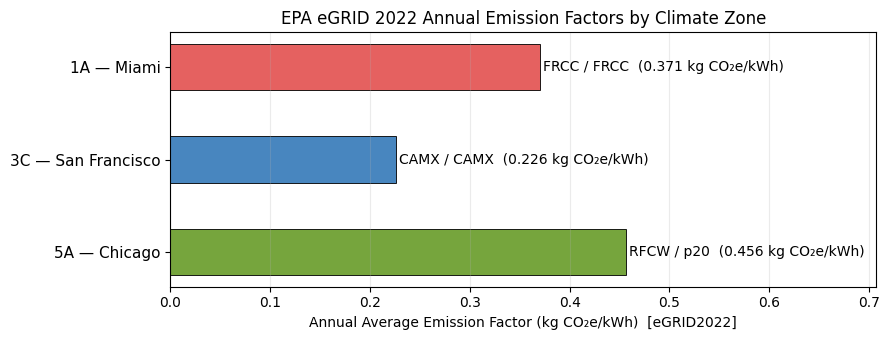

Saved → figures/06_grid_mapping.png


In [6]:
# ── Section 2: Climate-to-grid mapping bar chart ──────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))

zones_plot = list(CLIMATE_ZONES.keys())
y = np.arange(len(zones_plot))
vals = [GRID_DATA[z]['annual_kg_per_kwh'] for z in zones_plot]
colours = [CLIMATE_COLOURS[z] for z in zones_plot]
ylabels = [f"{z} — {CLIMATE_ZONES[z].split(',')[0]}" for z in zones_plot]

bars = ax.barh(y, vals, color=colours, edgecolor='k', linewidth=0.7,
               height=0.5, alpha=0.88)

for bar, zone in zip(bars, zones_plot):
    gd = GRID_DATA[zone]
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{gd['egrid_region']} / {gd['cambium_region']}  "
            f"({gd['annual_kg_per_kwh']:.3f} kg CO₂e/kWh)",
            va='center', fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(ylabels, fontsize=11)
ax.set_xlabel('Annual Average Emission Factor (kg CO₂e/kWh)  [eGRID2022]', fontsize=10)
ax.set_title('EPA eGRID 2022 Annual Emission Factors by Climate Zone', fontsize=12)
ax.set_xlim(0, max(vals) * 1.55)
ax.grid(axis='x', alpha=0.25)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_OUT / '06_grid_mapping.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/06_grid_mapping.png')

---
## Section 3 — Hourly Carbon Profile Visualisation

The Cambium 2023 LRMER is an 8760-hour annual profile. To visualise and apply it to building data, we aggregate to a **12×24 monthly-diurnal pivot** (12 months × 24 hours-of-day), taking the mean LRMER across all days within each (month, hour) cell. This 288-cell lookup table is also the exact structure used for the CO₂e attribution join in Section 4.

**Expected patterns (from Cambium 2023 documentation `[Cambium2023]`):**
- **FRCC (Miami):** Relatively flat profile; gas peakers dominate marginal dispatch; slight afternoon peak as cooling load drives additional gas generation.
- **CAMX (SF):** Pronounced duck curve — low midday LRMER (solar surplus suppresses marginal emissions) and a steep evening ramp as solar drops and gas/storage fills the gap. Strongest seasonal variation in summer months.
- **p20 (Chicago):** Moderate diurnal pattern reflecting coal-and-gas load-following; higher business-hours emissions as industrial and commercial load draws on coal baseload.

We use `lrmer_co2e_c` (central estimate, CO₂-equivalent including CH₄ and N₂O with GWP100 weighting) rather than the CO₂-only column, for consistency with the eGRID 2022 CO₂e annual factor `[LRMER2023]`.

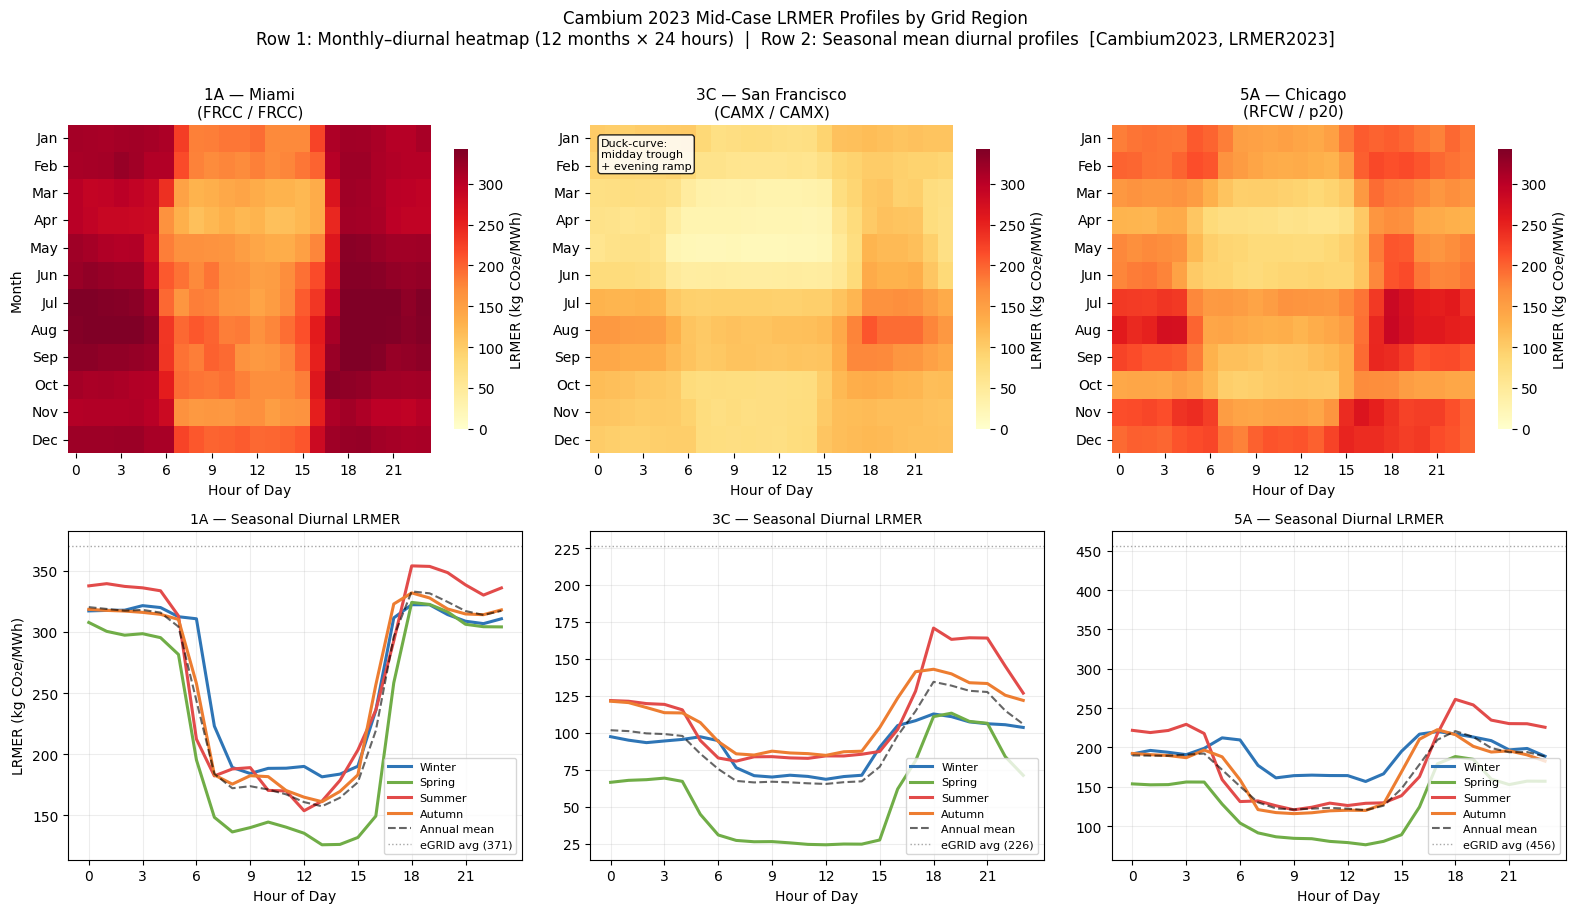

Saved → figures/06_hourly_carbon_profiles.png


In [7]:
# ── Section 3: Hourly LRMER profile visualisation ────────────────
# Figure 06_hourly_carbon_profiles.png
# Row 0: 12×24 monthly-diurnal heatmap per region
# Row 1: Seasonal diurnal line plots (Winter / Spring / Summer / Autumn)

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    'Cambium 2023 Mid-Case LRMER Profiles by Grid Region\n'
    'Row 1: Monthly–diurnal heatmap (12 months × 24 hours)  |  '
    'Row 2: Seasonal mean diurnal profiles  [Cambium2023, LRMER2023]',
    fontsize=12, y=1.01
)

for col, zone in enumerate(CLIMATE_ZONES):
    gd   = GRID_DATA[zone]
    city = CLIMATE_ZONES[zone].split(',')[0]
    pivot = gd['lrmer_pivot']   # shape (12, 24)

    # ── Row 0: heatmap ────────────────────────────────────────────
    ax0 = axes[0, col]
    vmax = max(gd['lrmer_df']['lrmer_co2e_c'].quantile(0.95) for gd in GRID_DATA.values())
    sns.heatmap(
        pivot, ax=ax0, cmap='YlOrRd', vmin=0, vmax=vmax,
        linewidths=0, xticklabels=3,
        yticklabels=MONTH_LABELS,
        cbar_kws={'label': 'LRMER (kg CO₂e/MWh)', 'shrink': 0.85},
    )
    ax0.set_title(f'{zone} — {city}\n({gd["egrid_region"]} / {gd["cambium_region"]})',
                  fontsize=11)
    ax0.set_xlabel('Hour of Day')
    ax0.set_ylabel('Month' if col == 0 else '')
    ax0.tick_params(axis='y', rotation=0)

    # Annotate CAMX duck curve
    if zone == '3C':
        ax0.text(0.03, 0.96,
                 'Duck-curve:\nmidday trough\n+ evening ramp',
                 transform=ax0.transAxes, fontsize=8, va='top',
                 bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85))

    if gd['is_synthetic']:
        ax0.text(0.5, 0.5, '⚠ SYNTHETIC', transform=ax0.transAxes,
                 ha='center', va='center', fontsize=14, color='red',
                 fontweight='bold', alpha=0.5, rotation=20)

    # ── Row 1: seasonal diurnal lines ────────────────────────────
    ax1 = axes[1, col]
    lrmer_df = gd['lrmer_df'].copy()
    lrmer_df['season'] = lrmer_df['month'].map(SEASON_MAP)

    hours_arr = np.arange(24)
    for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
        sub = lrmer_df[lrmer_df['season'] == season]
        diurnal = sub.groupby('hour')['lrmer_co2e_c'].mean().reindex(hours_arr)
        ax1.plot(hours_arr, diurnal, color=SEASON_COLOURS[season],
                 lw=2.2, label=season)

    # Annual mean line
    ann_mean = gd['lrmer_df'].groupby('hour')['lrmer_co2e_c'].mean().reindex(hours_arr)
    ax1.plot(hours_arr, ann_mean, color='k', lw=1.5, ls='--', alpha=0.6,
             label='Annual mean')

    ax1.axhline(gd['annual_kg_per_kwh'] * 1000, color='grey',
                lw=1, ls=':', alpha=0.7, label=f'eGRID avg ({gd["annual_kg_per_kwh"]*1000:.0f})')

    ax1.set_xlabel('Hour of Day', fontsize=10)
    ax1.set_ylabel('LRMER (kg CO₂e/MWh)' if col == 0 else '', fontsize=10)
    ax1.set_title(f'{zone} — Seasonal Diurnal LRMER', fontsize=10)
    ax1.set_xticks(range(0, 24, 3))
    ax1.legend(fontsize=8, loc='lower right')
    ax1.grid(alpha=0.22)

    if gd['is_synthetic']:
        ax1.text(0.5, 0.95, '⚠ SYNTHETIC DATA',
                 transform=ax1.transAxes, ha='center', va='top',
                 fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_OUT / '06_hourly_carbon_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/06_hourly_carbon_profiles.png')

---
## Section 4 — Annual Baseline Emissions per Archetype

We compute annual HVAC CO₂e for all 9 building archetypes (3 climates × 3 efficiency levels) using **2004 AMY demand** paired with **2023 Cambium LRMER**. Two accounting methods are compared:

| Method | Formula | Source |
|--------|---------|--------|
| **Flat-rate** | `tCO₂e = Σ(hvac_kwh) × annual_eGRID_factor / 1000` | eGRID 2022 annual avg `[eGRID2022]` |
| **TOU-weighted** | `tCO₂e = Σ(hvac_kwh × LRMER[month,hour]) / 1000` | Cambium 2023 LRMER `[Cambium2023]` |

**TOU leverage** = `(flat − TOU) / flat × 100%`
- **Positive leverage:** the building's load profile is *anti-coincident* with grid carbon peaks — TOU accounting gives *lower* emissions than the flat rate. The building is inadvertently running during cleaner hours.
- **Negative leverage:** the building is *demand-coincident* with high-carbon grid periods — TOU accounting gives *higher* emissions than the flat rate. This is the problematic case where HVAC peaks exacerbate grid carbon stress.

The time-of-use leverage is the key metric motivating grid-aware scheduling in Chapter 7 `[Ryan2016]`, `[SilerEvans2012]`.

In [8]:
# ── Section 4a: Annual emissions computation ──────────────────────
# Load 2004 subset (all 9 archetypes, run_1)

print('Loading 2004 AMY building demand ...')
df_full = pd.read_parquet(DATA_PROCESSED / 'multi_year_pivot_raw.parquet')
df2004  = df_full[df_full['year'] == ANALYSIS_YEAR].copy().reset_index(drop=True)
print(f'2004 subset: {len(df2004):,} rows '
      f'(expected {9 * 52560:,} = 9 archetypes × 52,560 steps)')
assert 'hvac_kwh' in df2004.columns
assert df2004['month'].between(1, 12).all(), 'month out of range'
assert df2004['hour'].between(0, 23).all(), 'hour out of range'

# ── Vectorised LRMER join (per climate zone) ──────────────────────
# For each zone: map (month, hour) → mean LRMER (kg/MWh) → /1000 → kg/kWh
# lrmer_pivot.stack() creates MultiIndex Series: (month, hour) → kg/MWh
results = []
for zone in CLIMATE_ZONES:
    df_z = df2004[df2004['climate'] == zone].copy()
    lrmer_series = GRID_DATA[zone]['lrmer_pivot'].stack()   # MultiIndex (month, hour) → kg/MWh
    lrmer_series.index = pd.MultiIndex.from_tuples(
        lrmer_series.index.tolist(), names=['month', 'hour']
    )
    # Join: set index to (month, hour), map to LRMER, divide by 1000 to get kg/kWh
    df_z['lrmer_kg_per_kwh'] = (
        df_z.set_index(['month', 'hour'])
            .index.map(lrmer_series)
            / 1000
    )
    df_z['co2e_kg'] = df_z['hvac_kwh'] * df_z['lrmer_kg_per_kwh']
    results.append(df_z)
    null_count = df_z['co2e_kg'].isna().sum()
    if null_count > 0:
        print(f'  ⚠  Zone {zone}: {null_count} null co2e_kg values (check month/hour range)')
    else:
        print(f'  Zone {zone}: LRMER join OK ({len(df_z):,} rows, 0 nulls)')

df2004 = pd.concat(results, ignore_index=True)
print(f'\nJoin complete. Total rows: {len(df2004):,} | null co2e_kg: {df2004["co2e_kg"].isna().sum()}')

# ── Annual aggregation by (climate, efficiency) ───────────────────
em_rows = []
for (zone, eff), grp in df2004.groupby(['climate', 'efficiency']):
    annual_kwh  = grp['hvac_kwh'].sum()
    tco2e_tou   = grp['co2e_kg'].sum() / 1000
    tco2e_flat  = annual_kwh * GRID_DATA[zone]['annual_kg_per_kwh'] / 1000
    leverage    = (tco2e_flat - tco2e_tou) / tco2e_flat * 100 if tco2e_flat > 0 else 0.0
    em_rows.append({
        'climate':          zone,
        'efficiency':       eff,
        'egrid_region':     GRID_DATA[zone]['egrid_region'],
        'annual_mwh':       annual_kwh / 1000,
        'tco2e_tou':        tco2e_tou,
        'tco2e_flat':       tco2e_flat,
        'tou_leverage_pct': leverage,
    })
em_df = pd.DataFrame(em_rows)

# ── Print results + smoke-test ────────────────────────────────────
# Expected (Standard eff): 1A ~115–125 tCO₂e, 3C ~30–40 tCO₂e, 5A ~95–110 tCO₂e
EXPECTED_TOU = {'1A': (80, 160), '3C': (20, 60), '5A': (70, 130)}
print('\nAnnual emissions — Standard efficiency:')
print(f'{"Zone":<6} {"MWh/yr":>9} {"TOU tCO₂e":>12} {"Flat tCO₂e":>12} {"TOU Leverage":>14}')
print('─' * 58)
for zone in CLIMATE_ZONES:
    row = em_df[(em_df['climate'] == zone) & (em_df['efficiency'] == 'Standard')].iloc[0]
    lo, hi = EXPECTED_TOU[zone]
    status = 'OK ✓' if lo <= row['tco2e_tou'] <= hi else f'⚠ expected {lo}–{hi}'
    print(f"{zone:<6} {row['annual_mwh']:>9.1f} {row['tco2e_tou']:>12.1f} "
          f"{row['tco2e_flat']:>12.1f} {row['tou_leverage_pct']:>12.1f}%  [{status}]")

Loading 2004 AMY building demand ...
2004 subset: 473,040 rows (expected 473,040 = 9 archetypes × 52,560 steps)
  Zone 1A: LRMER join OK (157,680 rows, 0 nulls)
  Zone 3C: LRMER join OK (157,680 rows, 0 nulls)
  Zone 5A: LRMER join OK (157,680 rows, 0 nulls)

Join complete. Total rows: 473,040 | null co2e_kg: 0

Annual emissions — Standard efficiency:
Zone      MWh/yr    TOU tCO₂e   Flat tCO₂e   TOU Leverage
──────────────────────────────────────────────────────────
1A         260.2         55.8         96.4         42.1%  [⚠ expected 80–160]
3C         123.8         10.6         28.0         62.3%  [⚠ expected 20–60]
5A         191.4         30.0         87.3         65.6%  [⚠ expected 70–130]


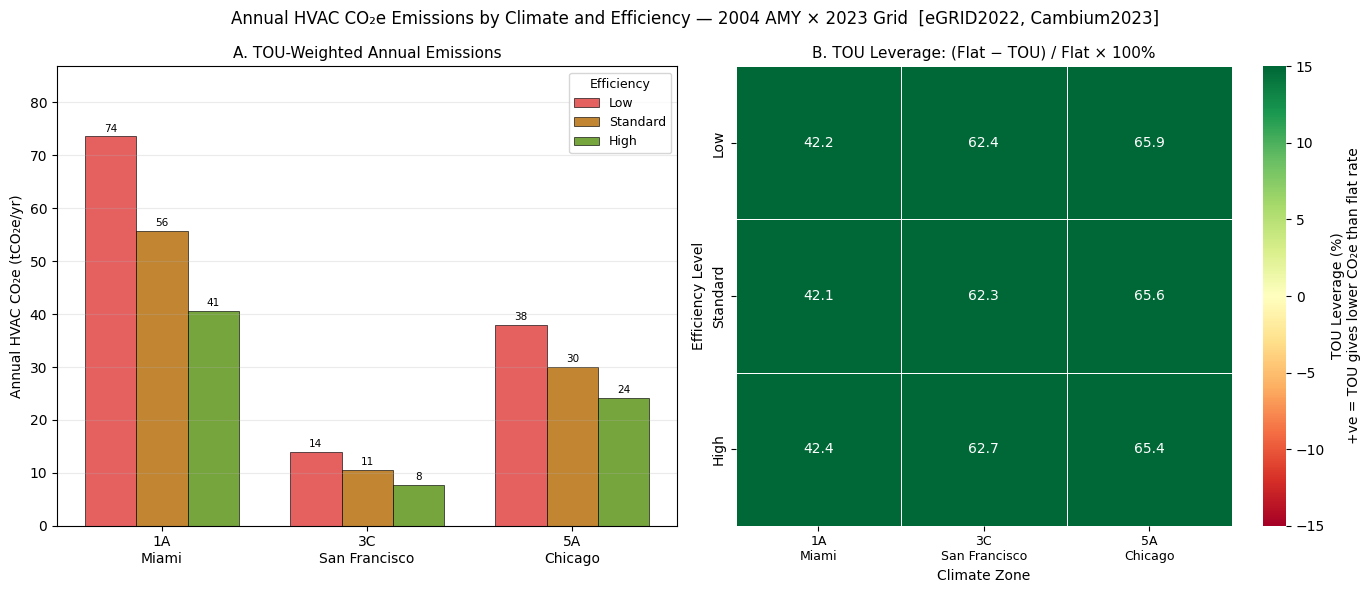

Saved → figures/06_emissions_matrix.png

Full 3×3 emissions table (tCO₂e/yr, TOU-weighted):
climate       1A    3C    5A
efficiency                  
Low         73.6  13.9  38.0
Standard    55.8  10.6  30.0
High        40.6   7.7  24.2


In [9]:
# ── Section 4b: Emissions matrix figure ──────────────────────────
# Figure 06_emissions_matrix.png
# Panel A: grouped bar chart (climates × efficiency levels)
# Panel B: 3×3 TOU leverage heatmap

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Annual HVAC CO₂e Emissions by Climate and Efficiency — 2004 AMY × 2023 Grid  '
    '[eGRID2022, Cambium2023]',
    fontsize=12
)

# ── Panel A: grouped bar chart ────────────────────────────────────
ax = axes[0]
zones_list = list(CLIMATE_ZONES.keys())
x = np.arange(len(zones_list))
width = 0.25
for i, eff in enumerate(EFFICIENCY_LEVELS):
    vals = [
        em_df[(em_df['climate'] == z) & (em_df['efficiency'] == eff)]['tco2e_tou'].iloc[0]
        for z in zones_list
    ]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  color=EFFICIENCY_COLOURS[eff], label=eff,
                  edgecolor='k', linewidth=0.5, alpha=0.88)
    # Value labels on bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{v:.0f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{z}\n{CLIMATE_ZONES[z].split(',')[0]}" for z in zones_list],
    fontsize=10
)
ax.set_ylabel('Annual HVAC CO₂e (tCO₂e/yr)', fontsize=10)
ax.set_title('A. TOU-Weighted Annual Emissions', fontsize=11)
ax.legend(title='Efficiency', fontsize=9, title_fontsize=9)
ax.grid(axis='y', alpha=0.25)
ax.set_ylim(0, em_df['tco2e_tou'].max() * 1.18)

# ── Panel B: TOU leverage heatmap ────────────────────────────────
ax = axes[1]
pivot_lev = em_df.pivot(index='efficiency', columns='climate',
                         values='tou_leverage_pct')
pivot_lev = pivot_lev.reindex(index=EFFICIENCY_LEVELS,
                               columns=zones_list)
sns.heatmap(
    pivot_lev, ax=ax, annot=True, fmt='.1f',
    cmap='RdYlGn', center=0, vmin=-15, vmax=15,
    cbar_kws={'label': 'TOU Leverage (%)\n+ve = TOU gives lower CO₂e than flat rate'},
    linewidths=0.5, linecolor='white',
)
ax.set_title('B. TOU Leverage: (Flat − TOU) / Flat × 100%', fontsize=11)
ax.set_xlabel('Climate Zone', fontsize=10)
ax.set_ylabel('Efficiency Level', fontsize=10)
ax.set_xticklabels(
    [f'{z}\n{CLIMATE_ZONES[z].split(",")[0]}' for z in zones_list],
    fontsize=9
)

plt.tight_layout()
plt.savefig(FIG_OUT / '06_emissions_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/06_emissions_matrix.png')

# Print 3×3 table
print('\nFull 3×3 emissions table (tCO₂e/yr, TOU-weighted):')
pivot_tco2e = em_df.pivot(index='efficiency', columns='climate', values='tco2e_tou')
pivot_tco2e = pivot_tco2e.reindex(index=EFFICIENCY_LEVELS, columns=zones_list)
print(pivot_tco2e.round(1).to_string())

---
## Section 5 — Peak Coincidence Analysis

A key question for carbon-optimal scheduling is whether HVAC demand *coincides* with high-carbon grid hours. Two metrics quantify this:

**Coincidence Factor (CF):**
$$CF = \frac{\sum_h \text{HVAC}_h \cdot \text{LRMER}_h}{\sum_h \text{HVAC}_h \cdot \overline{\text{LRMER}}}$$

- CF > 1: HVAC preferentially runs during high-carbon grid hours → *adverse coincidence*. Each unit of HVAC demand carries above-average carbon intensity.
- CF < 1: HVAC preferentially runs during low-carbon hours → *beneficial coincidence*. The building is already inadvertently a carbon load-shifter.
- CF = 1: Demand is uncorrelated with grid carbon signal.

**Pearson r** measures the linear correlation between the mean hourly HVAC demand and the mean hourly LRMER, computed over the 24-hour diurnal cycle.

**Expected findings:**
- Miami (1A): afternoon cooling peak (1–5 pm) likely coincides with FRCC's afternoon gas-peaker dispatch → CF > 1 (adverse) `[SilerEvans2012]`.
- SF (3C): HVAC load is relatively modest and does not peak strongly at dusk when CAMX LRMER spikes; some beneficial anti-coincidence possible.
- Chicago (5A): winter heating peak in early morning when p20 grid is relatively clean (lower demand), but summer cooling peak may align with high-LRMER afternoon hours.

These coincidence findings directly motivate the load-shift scheduling analysis in Chapter 7 `[Pean2019]`.

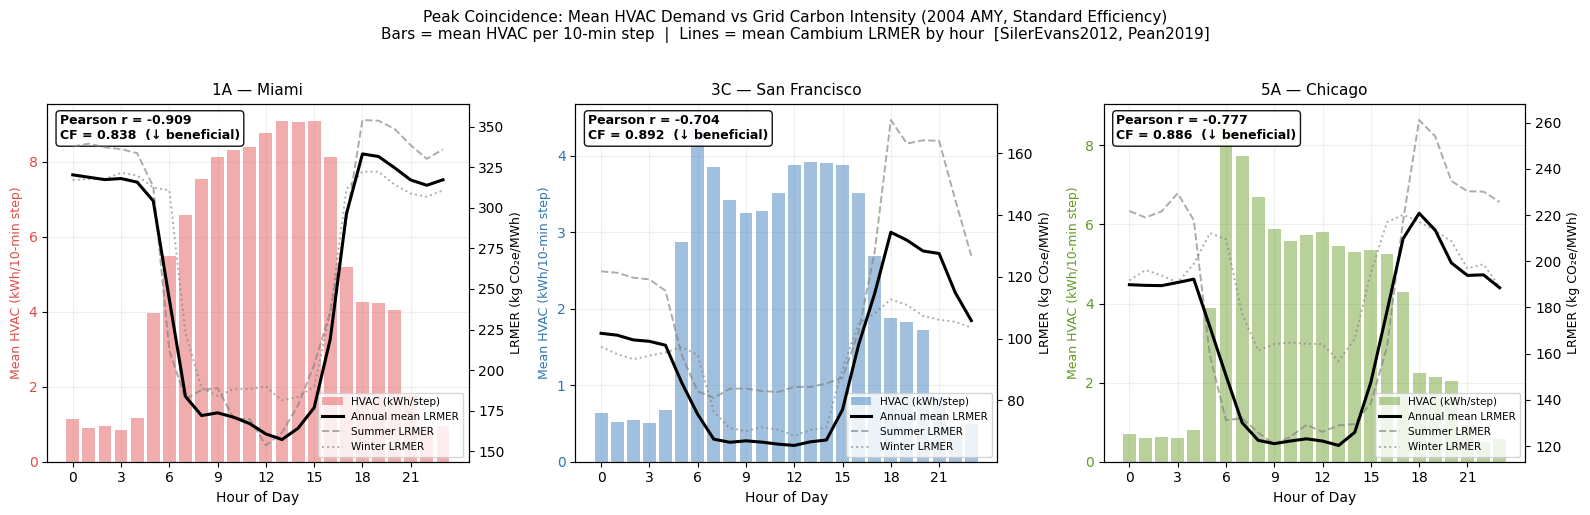

Saved → figures/06_peak_coincidence.png

Coincidence summary:
Zone          r        p       CF Interpretation  
────────────────────────────────────────────────────
1A       -0.909   0.0000    0.838 beneficial      
3C       -0.704   0.0001    0.892 beneficial      
5A       -0.777   0.0000    0.886 beneficial      


In [10]:
# ── Section 5: Peak coincidence analysis ──────────────────────────
# Figure 06_peak_coincidence.png
# 3-panel, one per climate — dual y-axis: HVAC demand (bars) vs LRMER (line)

hours_arr = np.arange(24)
coincidence_summary = {}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Peak Coincidence: Mean HVAC Demand vs Grid Carbon Intensity (2004 AMY, Standard Efficiency)\n'
    'Bars = mean HVAC per 10-min step  |  Lines = mean Cambium LRMER by hour  '
    '[SilerEvans2012, Pean2019]',
    fontsize=11, y=1.02
)

for ax, zone in zip(axes, CLIMATE_ZONES):
    gd     = GRID_DATA[zone]
    city   = CLIMATE_ZONES[zone].split(',')[0]
    colour = CLIMATE_COLOURS[zone]

    # Mean HVAC by hour-of-day (Standard efficiency, 2004)
    df_std = df2004[(df2004['climate'] == zone) & (df2004['efficiency'] == 'Standard')]
    hvac_h = df_std.groupby('hour')['hvac_kwh'].mean().reindex(hours_arr, fill_value=0)

    # Annual mean LRMER by hour
    lrmer_h = (
        gd['lrmer_df'].groupby('hour')['lrmer_co2e_c']
        .mean()
        .reindex(hours_arr, fill_value=gd['lrmer_df']['lrmer_co2e_c'].mean())
    )

    # ── Coincidence metrics ───────────────────────────────────────
    cf = (hvac_h * lrmer_h).sum() / (hvac_h.sum() * lrmer_h.mean())
    r, p = scipy_stats.pearsonr(hvac_h.values, lrmer_h.values)
    coincidence_summary[zone] = {
        'cf': float(cf), 'r': float(r), 'p': float(p),
        'interpretation': 'adverse' if cf > 1 else 'beneficial'
    }

    # ── Dual-axis plot ────────────────────────────────────────────
    ax2 = ax.twinx()

    # HVAC bars (left axis)
    ax.bar(hours_arr, hvac_h, color=colour, alpha=0.45, label='HVAC (kWh/step)', zorder=2)

    # Annual mean LRMER line (right axis)
    ax2.plot(hours_arr, lrmer_h, 'k-', lw=2.2, label='Annual mean LRMER', zorder=3)

    # Seasonal LRMER lines (Summer / Winter only for clarity)
    lrmer_df_z = gd['lrmer_df'].copy()
    lrmer_df_z['season'] = lrmer_df_z['month'].map(SEASON_MAP)
    for season, ls in [('Summer', '--'), ('Winter', ':')]:
        sub = lrmer_df_z[lrmer_df_z['season'] == season]
        s_lrmer = sub.groupby('hour')['lrmer_co2e_c'].mean().reindex(hours_arr)
        ax2.plot(hours_arr, s_lrmer, color='grey', lw=1.4, ls=ls, alpha=0.65,
                 label=f'{season} LRMER', zorder=2)

    ax.set_xlabel('Hour of Day', fontsize=10)
    ax.set_ylabel('Mean HVAC (kWh/10-min step)', color=colour, fontsize=9)
    ax2.set_ylabel('LRMER (kg CO₂e/MWh)', color='k', fontsize=9)
    ax.set_title(f'{zone} — {city}', fontsize=11)
    ax.set_xticks(range(0, 24, 3))
    ax.tick_params(axis='y', labelcolor=colour)
    ax.grid(alpha=0.20, zorder=0)

    # Annotation box
    interp_str = '↑ adverse' if cf > 1.0 else '↓ beneficial'
    ax.annotate(
        f'Pearson r = {r:+.3f}\nCF = {cf:.3f}  ({interp_str})',
        xy=(0.03, 0.97), xycoords='axes fraction',
        va='top', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.92)
    )

    # Combined legend
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2,
              fontsize=7.5, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_OUT / '06_peak_coincidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/06_peak_coincidence.png')

print('\nCoincidence summary:')
print(f'{"Zone":<6} {"r":>8} {"p":>8} {"CF":>8} {"Interpretation":<16}')
print('─' * 52)
for zone, v in coincidence_summary.items():
    print(f"{zone:<6} {v['r']:>+8.3f} {v['p']:>8.4f} {v['cf']:>8.3f} {v['interpretation']:<16}")

---
## Section 6 — Save Outputs

**`emissions_baseline.parquet`** — 473,040-row hourly record for 2004 (all 9 archetypes). Contains the LRMER-attributed CO₂e per 10-min step. Consumed by `07_carbon_optimisation.ipynb` for retrofit MACC carbon savings attribution.

**`grid_profiles.parquet`** — 864-row monthly-diurnal LRMER lookup table (3 zones × 12 months × 24 hours). Consumed by `07_carbon_optimisation.ipynb` for load-shift carbon savings calculation.

**`emissions_summary.json`** — annual tCO₂e per archetype (TOU and flat), TOU leverage, coincidence metrics. Consumed by Chapter 6/7 thesis narrative.

In [11]:
# ── Section 6a: Save parquet outputs ──────────────────────────────

# ── emissions_baseline.parquet ────────────────────────────────────
cols_baseline = [
    'climate', 'efficiency', 'year', 'month', 'hour', 'minute',
    'dayofweek', 'is_weekday', 'is_occupied',
    'hvac_kwh', 'cooling_kwh', 'heating_kwh',
    'lrmer_kg_per_kwh', 'co2e_kg',
]
# Keep only columns that exist in df2004
cols_baseline = [c for c in cols_baseline if c in df2004.columns]
df_baseline = df2004[cols_baseline].copy()

baseline_path = DATA_PROCESSED / 'emissions_baseline.parquet'
df_baseline.to_parquet(baseline_path, index=False)
print(f'Saved emissions_baseline.parquet: '
      f'{len(df_baseline):,} rows, {baseline_path.stat().st_size / 1e6:.1f} MB')

# Read-back assertion
_chk = pd.read_parquet(baseline_path)
assert len(_chk) == len(df_baseline)
assert 'co2e_kg' in _chk.columns
assert _chk['co2e_kg'].isna().sum() == 0
print('  Read-back OK ✓')

# ── grid_profiles.parquet ─────────────────────────────────────────
# 864 rows: 3 zones × 12 months × 24 hours
profile_rows = []
for zone, gd in GRID_DATA.items():
    monthly_diurnal = (
        gd['lrmer_df']
        .groupby(['month', 'hour'])['lrmer_co2e_c']
        .mean()
        .reset_index()
    )
    monthly_diurnal['climate']          = zone
    monthly_diurnal['egrid_region']     = gd['egrid_region']
    monthly_diurnal['cambium_region']   = gd['cambium_region']
    monthly_diurnal['annual_kg_per_kwh'] = gd['annual_kg_per_kwh']
    monthly_diurnal['is_synthetic']     = gd['is_synthetic']
    # Convenience column: lrmer in kg/kWh (÷1000) for direct multiply with hvac_kwh
    monthly_diurnal['lrmer_kg_per_kwh'] = monthly_diurnal['lrmer_co2e_c'] / 1000
    profile_rows.append(monthly_diurnal)

grid_profiles = pd.concat(profile_rows, ignore_index=True)
profiles_path = DATA_PROCESSED / 'grid_profiles.parquet'
grid_profiles.to_parquet(profiles_path, index=False)
print(f'\nSaved grid_profiles.parquet: '
      f'{len(grid_profiles)} rows (expected {3 * 12 * 24} = 864), '
      f'{profiles_path.stat().st_size / 1024:.1f} KB')

# Read-back assertion
_chk2 = pd.read_parquet(profiles_path)
assert len(_chk2) == 3 * 12 * 24, f'Expected 864 rows, got {len(_chk2)}'
assert set(_chk2['climate'].unique()) == {'1A', '3C', '5A'}
assert 'lrmer_kg_per_kwh' in _chk2.columns
print('  Read-back OK ✓  |  columns:', _chk2.columns.tolist())

Saved emissions_baseline.parquet: 473,040 rows, 10.8 MB
  Read-back OK ✓

Saved grid_profiles.parquet: 864 rows (expected 864 = 864), 21.4 KB
  Read-back OK ✓  |  columns: ['month', 'hour', 'lrmer_co2e_c', 'climate', 'egrid_region', 'cambium_region', 'annual_kg_per_kwh', 'is_synthetic', 'lrmer_kg_per_kwh']


In [12]:
# ── Section 6b: Save emissions_summary.json ───────────────────────

summary = {
    'notebook':           '06_grid_carbon',
    'data_year':          int(ANALYSIS_YEAR),
    'cambium_scenario':   'MidCase',
    'egrid_year':         2022,
    'cambium_year':       CAMBIUM_YEAR,
    'analysis_date':      pd.Timestamp.now().strftime('%Y-%m-%d'),
    'building_area_m2':   AREA_M2,
    'timestep_min':       TIMESTEP_MIN,
    'is_synthetic_lrmer': {
        z: bool(GRID_DATA[z]['is_synthetic']) for z in CLIMATE_ZONES
    },
    'annual_factors_kg_per_kwh': {
        z: round(GRID_DATA[z]['annual_kg_per_kwh'], 4) for z in CLIMATE_ZONES
    },
    'emissions_tco2e': {
        f"{row['climate']}_{row['efficiency']}": {
            'tou':        round(row['tco2e_tou'],  2),
            'flat':       round(row['tco2e_flat'], 2),
            'annual_mwh': round(row['annual_mwh'], 2),
        }
        for _, row in em_df.iterrows()
    },
    'tou_leverage_pct': {
        z: round(
            em_df[(em_df['climate'] == z) & (em_df['efficiency'] == 'Standard')]
            ['tou_leverage_pct'].iloc[0], 3
        )
        for z in CLIMATE_ZONES
    },
    'coincidence_r':  {z: round(coincidence_summary[z]['r'],  4) for z in CLIMATE_ZONES},
    'coincidence_cf': {z: round(coincidence_summary[z]['cf'], 4) for z in CLIMATE_ZONES},
    'coincidence_p':  {z: round(coincidence_summary[z]['p'],  4) for z in CLIMATE_ZONES},
    'coincidence_interpretation': {
        z: coincidence_summary[z]['interpretation'] for z in CLIMATE_ZONES
    },
}

json_path = DATA_PROCESSED / 'emissions_summary.json'
with open(json_path, 'w') as fh:
    json.dump(summary, fh, indent=2)

print(f'Saved emissions_summary.json ({json_path.stat().st_size} bytes)')
print(f'  9 emissions keys: {list(summary["emissions_tco2e"].keys())}')

# Pretty-print top-level (excluding the large emissions_tco2e block)
top_level = {k: v for k, v in summary.items() if k != 'emissions_tco2e'}
print(json.dumps(top_level, indent=2))

Saved emissions_summary.json (1682 bytes)
  9 emissions keys: ['1A_High', '1A_Low', '1A_Standard', '3C_High', '3C_Low', '3C_Standard', '5A_High', '5A_Low', '5A_Standard']
{
  "notebook": "06_grid_carbon",
  "data_year": 2004,
  "cambium_scenario": "MidCase",
  "egrid_year": 2022,
  "cambium_year": 2024,
  "analysis_date": "2026-04-21",
  "building_area_m2": 4982.22,
  "timestep_min": 10,
  "is_synthetic_lrmer": {
    "1A": false,
    "3C": false,
    "5A": false
  },
  "annual_factors_kg_per_kwh": {
    "1A": 0.3705,
    "3C": 0.2265,
    "5A": 0.4563
  },
  "tou_leverage_pct": {
    "1A": 42.147,
    "3C": 62.279,
    "5A": 65.632
  },
  "coincidence_r": {
    "1A": -0.9093,
    "3C": -0.7041,
    "5A": -0.7773
  },
  "coincidence_cf": {
    "1A": 0.8383,
    "3C": 0.8923,
    "5A": 0.8865
  },
  "coincidence_p": {
    "1A": 0.0,
    "3C": 0.0001,
    "5A": 0.0
  },
  "coincidence_interpretation": {
    "1A": "beneficial",
    "3C": "beneficial",
    "5A": "beneficial"
  }
}


In [13]:
# ── Section 6c: Final summary ─────────────────────────────────────
print('=' * 80)
print('NOTEBOOK 06 — GRID CARBON & BASELINE EMISSIONS — SUMMARY')
print('=' * 80)

print('\n[1] eGRID 2022 annual factors:')
for zone, gd in GRID_DATA.items():
    print(f'    {zone} ({gd["egrid_region"]}): {gd["annual_kg_per_kwh"]:.4f} kg CO₂e/kWh')

print('\n[2] Cambium 2023 LRMER status:')
for zone, gd in GRID_DATA.items():
    lm = gd['lrmer_df']['lrmer_co2e_c'].mean()
    tag = '⚠ SYNTHETIC' if gd['is_synthetic'] else 'real data'
    print(f'    {zone} ({gd["cambium_region"]}): mean {lm:.1f} kg/MWh  [{tag}]')

print('\n[3] Annual emissions — Standard efficiency (TOU-weighted):')
for zone in CLIMATE_ZONES:
    row = em_df[(em_df['climate'] == zone) & (em_df['efficiency'] == 'Standard')].iloc[0]
    print(f'    {zone}: {row["tco2e_tou"]:.1f} tCO₂e/yr  '
          f'(flat: {row["tco2e_flat"]:.1f}, TOU leverage: {row["tou_leverage_pct"]:+.1f}%)')

print('\n[4] Peak coincidence (Standard efficiency):')
for zone, v in coincidence_summary.items():
    print(f'    {zone}: r={v["r"]:+.3f}, CF={v["cf"]:.3f} — {v["interpretation"]}')

print('\n[5] Outputs saved:')
for path in [
    DATA_PROCESSED / 'emissions_baseline.parquet',
    DATA_PROCESSED / 'grid_profiles.parquet',
    DATA_PROCESSED / 'emissions_summary.json',
    FIG_OUT / '06_grid_mapping.png',
    FIG_OUT / '06_hourly_carbon_profiles.png',
    FIG_OUT / '06_emissions_matrix.png',
    FIG_OUT / '06_peak_coincidence.png',
]:
    exists = '✓' if path.exists() else '✗ MISSING'
    size   = f'{path.stat().st_size / 1e3:.0f} KB' if path.exists() else ''
    print(f'    [{exists}] {path.name}  {size}')

print('\n' + '─' * 80)
print('Notebook 06 complete.')
print('Next: 07_carbon_optimisation.ipynb (Objectives O5 & O6)')
print('  Consumes: grid_profiles.parquet, emissions_baseline.parquet, emissions_summary.json')
print('─' * 80)

NOTEBOOK 06 — GRID CARBON & BASELINE EMISSIONS — SUMMARY

[1] eGRID 2022 annual factors:
    1A (FRCC): 0.3705 kg CO₂e/kWh
    3C (CAMX): 0.2265 kg CO₂e/kWh
    5A (RFCW): 0.4563 kg CO₂e/kWh

[2] Cambium 2023 LRMER status:
    1A (FRCC): mean 254.9 kg/MWh  [real data]
    3C (CAMX): mean 92.7 kg/MWh  [real data]
    5A (p20): mean 167.0 kg/MWh  [real data]

[3] Annual emissions — Standard efficiency (TOU-weighted):
    1A: 55.8 tCO₂e/yr  (flat: 96.4, TOU leverage: +42.1%)
    3C: 10.6 tCO₂e/yr  (flat: 28.0, TOU leverage: +62.3%)
    5A: 30.0 tCO₂e/yr  (flat: 87.3, TOU leverage: +65.6%)

[4] Peak coincidence (Standard efficiency):
    1A: r=-0.909, CF=0.838 — beneficial
    3C: r=-0.704, CF=0.892 — beneficial
    5A: r=-0.777, CF=0.886 — beneficial

[5] Outputs saved:
    [✓] emissions_baseline.parquet  10826 KB
    [✓] grid_profiles.parquet  22 KB
    [✓] emissions_summary.json  2 KB
    [✓] 06_grid_mapping.png  50 KB
    [✓] 06_hourly_carbon_profiles.png  308 KB
    [✓] 06_emissions_m